# Visual conceptual space test


In [11]:
import os
import sys

sys.path.insert(0, os.path.abspath('../src'))


In [12]:
import csv
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from core import Scene
from processors import VisualConceptExtractor
from structures import ConceptMemory

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'CMU Serif', 'DejaVu Serif'],
    'text.usetex': True,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
    'savefig.dpi': 300,
})


## Load scenes


In [13]:
manifest_path = Path('visual_manifest.csv')
scene_dir = Path('test_scenes')

with manifest_path.open(newline='') as f:
    records = list(csv.DictReader(f))

records


[{'scene_file': 'scene_crop_b=8_bt=0.5_pe=1_pose-transl_box.joblib',
  'object_id': '1',
  'label': 'box',
  'object': 'box',
  'motion_label': 'translation',
  'has_motion': 'yes',
  'usable_pose': 'yes',
  'notes': 'box visual record from successful translation run'},
 {'scene_file': 'scene_crop_b=8_bt=0.5_pe=1_pose-dtransl_box.joblib',
  'object_id': '1',
  'label': 'box',
  'object': 'box',
  'motion_label': 'depth_translation',
  'has_motion': 'yes',
  'usable_pose': 'yes',
  'notes': 'box visual record from successful depth-translation run'},
 {'scene_file': 'scene_crop_b=8_bt=0.5_pe=1_pose-transl_boat.joblib',
  'object_id': '3',
  'label': 'boat',
  'object': 'boat',
  'motion_label': 'translation',
  'has_motion': 'yes',
  'usable_pose': 'partial',
  'notes': 'boat visual record from translation run'},
 {'scene_file': 'scene_crop_b=8_bt=0.5_pe=1_pose-rot_boat.joblib',
  'object_id': '1',
  'label': 'boat',
  'object': 'boat',
  'motion_label': 'rotation',
  'has_motion': 'yes'

In [14]:
def select_object(scene, obj_id):
    if obj_id != 'auto':
        return scene[int(obj_id)]

    candidates = [
        obj for obj in scene
        if obj.num_snapshots > 0
    ]
    if not candidates:
        raise ValueError('No object with snapshots found')

    return max(
        candidates,
        key=lambda obj: (
            obj.num_snapshots,
            obj.num_poses,
            obj.last_seen.area
        )
    )


extractor = VisualConceptExtractor()
points = []

for record in records:
    scene_path = scene_dir / record['scene_file']
    scene = Scene.load(str(scene_path))
    obj = select_object(scene, record['object_id'])

    point = extractor(
        obj.snapshots,
        label=record['label'],
        metadata={
            **record,
            'object_id': obj.obj_id,
            'num_snapshots': obj.num_snapshots,
        }
    )
    points.append(point)

memory = ConceptMemory.from_points(extractor.space, points)
memory, memory.vectors.shape


(<ConceptMemory with 5 points in R^54>, (5, 54))

In [15]:
for point in memory:
    print(
        f"{point.label:<5} "
        f"motion={point.metadata.get('motion_label'):<18} "
        f"has_motion={point.metadata.get('has_motion'):<3} "
        f"snapshots={point.metadata.get('num_snapshots'):<3} "
        f"usable={point.metadata.get('usable_pose')} "
        f"obj={point.metadata.get('object_id')}"
    )


box   motion=translation        has_motion=yes snapshots=2   usable=yes obj=1
box   motion=depth_translation  has_motion=yes snapshots=2   usable=yes obj=1
boat  motion=translation        has_motion=yes snapshots=6   usable=partial obj=3
boat  motion=rotation           has_motion=yes snapshots=7   usable=no obj=1
ball  motion=roll               has_motion=no  snapshots=8   usable=no obj=1


## Visual descriptors


In [16]:
for name, value in zip(extractor.domain.names, memory.vectors.mean(axis=0)):
    print(f'{name:<20} {value:.3f}')


mask_area_ratio      0.635
mask_aspect_ratio    1.477
mask_extent          0.726
mask_solidity        0.854
mask_compactness     0.538
mask_eccentricity    0.740
hu_0                 0.611
hu_1                 2.195
hu_2                 3.625
hu_3                 4.131
hu_4                 4.218
hu_5                 -0.708
hu_6                 -0.178
hsv_hist_0           0.035
hsv_hist_1           0.001
hsv_hist_2           0.000
hsv_hist_3           0.000
hsv_hist_4           0.144
hsv_hist_5           0.001
hsv_hist_6           0.000
hsv_hist_7           0.000
hsv_hist_8           0.022
hsv_hist_9           0.003
hsv_hist_10          0.002
hsv_hist_11          0.002
hsv_hist_12          0.023
hsv_hist_13          0.007
hsv_hist_14          0.014
hsv_hist_15          0.003
hsv_hist_16          0.329
hsv_hist_17          0.166
hsv_hist_18          0.145
hsv_hist_19          0.078
hsv_hist_20          0.014
hsv_hist_21          0.005
hsv_hist_22          0.001
hsv_hist_23          0.001

In [17]:
X = memory.vectors
mu = X.mean(axis=0)
sigma = X.std(axis=0)
sigma[sigma == 0] = 1.0
X_norm = (X - mu) / sigma

U, S, Vt = np.linalg.svd(X_norm, full_matrices=False)
proj = X_norm @ Vt[:2].T
explained = (S ** 2) / np.maximum(len(X_norm) - 1, 1)
explained = explained / explained.sum() if explained.sum() > 0 else explained

proj.shape, explained[:2]


((5, 2), array([    0.43637,     0.27274]))

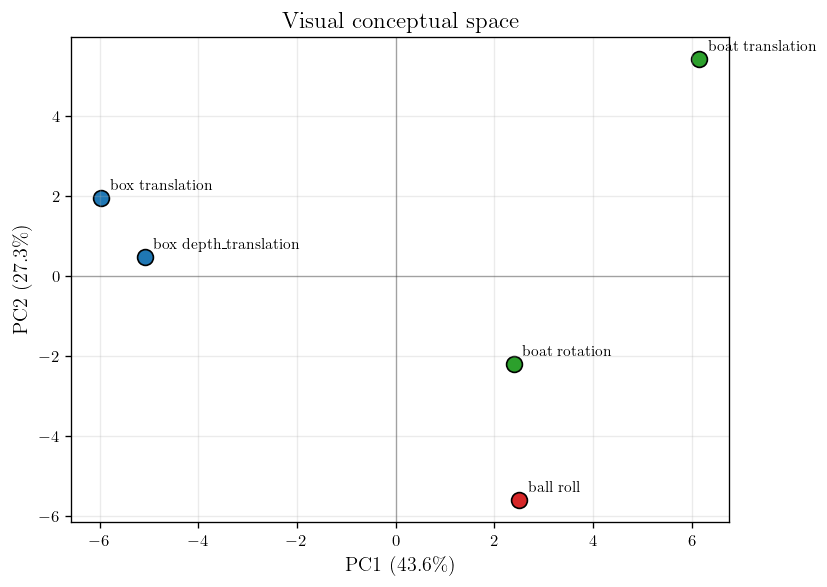

In [18]:
object_colors = {
    'box': 'C0',
    'boat': 'C2',
    'ball': 'C3',
}

fig, ax = plt.subplots(figsize=(7, 5))

for idx, point in enumerate(memory):
    ax.scatter(
        proj[idx, 0], proj[idx, 1],
        color=object_colors.get(point.label, '0.4'),
        s=90,
        edgecolor='black',
        linewidth=1,
    )
    ax.annotate(
        f"{point.label} {point.metadata.get('motion_label')}",
        (proj[idx, 0], proj[idx, 1]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
    )

ax.axhline(0, color='0.2', linewidth=0.8, alpha=0.4)
ax.axvline(0, color='0.2', linewidth=0.8, alpha=0.4)
ax.set_xlabel(rf'PC1 ({explained[0] * 100:.1f}\%)')
ax.set_ylabel(rf'PC2 ({explained[1] * 100:.1f}\%)')
ax.set_title('Visual conceptual space')
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()


## Prototypes


In [19]:
prototypes = memory.prototypes()

for label, proto in prototypes.items():
    print(label, proto)


box <ConceptPrototype "box" supported by 2 exemplars in R^54>
boat <ConceptPrototype "boat" supported by 2 exemplars in R^54>
ball <ConceptPrototype "ball" supported by 1 exemplars in R^54>


In [20]:
for point in memory:
    print(f'{point.label} ({point.metadata.get("motion_label")})')
    for label, proto in prototypes.items():
        dist = memory.space.distance(point, proto)
        print(f'  to {label:<8}: {dist:.3f}')


box (translation)
  to box     : 8.778
  to boat    : 20.000
  to ball    : 18.240
box (depth_translation)
  to box     : 8.778
  to boat    : 8.831
  to ball    : 4.937
boat (translation)
  to box     : 11.670
  to boat    : 3.979
  to ball    : 5.239
boat (rotation)
  to box     : 14.810
  to boat    : 3.979
  to ball    : 8.920
ball (roll)
  to box     : 10.074
  to boat    : 6.138
  to ball    : 0.000
